In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as scs
import scipy.special as sps


In [20]:
x = np.linspace(0, 5, 100)
def S(x, n=2):
    return np.sum([np.exp(-n)*(n**k)/sps.factorial(k) for k in range(0, int(n+np.sqrt(n)*x)+1)])



In [23]:
S_x = np.array([S(xi, 1) for xi in x])
S_x_etendu = np.concatenate([np.zeros(len(x)), S_x])
x = np.linspace(-5, 5, 200)


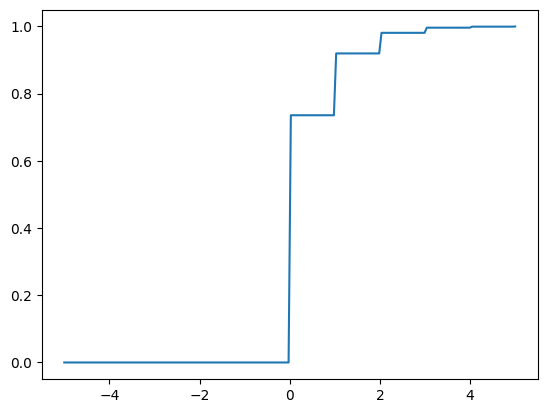

In [25]:
plt.plot(x, S_x_etendu)

In [26]:
S(3, 1)

np.float64(0.9963401531726563)

In [27]:
F = scs.norm.cdf(x, loc=0, scale=1)

In [16]:
S_x[80:]-F[80:]

array([-5.67505220e-04, -5.72700540e-04, -5.76926264e-04, -5.80354591e-04,
       -5.83128908e-04, -5.85368259e-04, -5.87171197e-04, -5.88619075e-04,
       -5.89778854e-04, -5.90705495e-04, -5.91443976e-04, -5.92031007e-04,
       -5.92496458e-04, -5.92864570e-04, -5.93154957e-04, -5.93383448e-04,
       -5.93562777e-04, -5.93703165e-04, -5.93812786e-04, -8.29544977e-05])

In [8]:
[S(3, i) for i in range(1, 10)]

[np.float64(0.9963401531726563),
 np.float64(0.9954661944737513),
 np.float64(0.9961970079383241),
 np.float64(0.997160233879486),
 np.float64(0.9945469080869906),
 np.float64(0.9963715072612774),
 np.float64(0.994282797507504),
 np.float64(0.996281978718716),
 np.float64(0.9975735978120195)]

In [9]:
scs.norm.cdf(-3)

np.float64(0.001349898031630093)

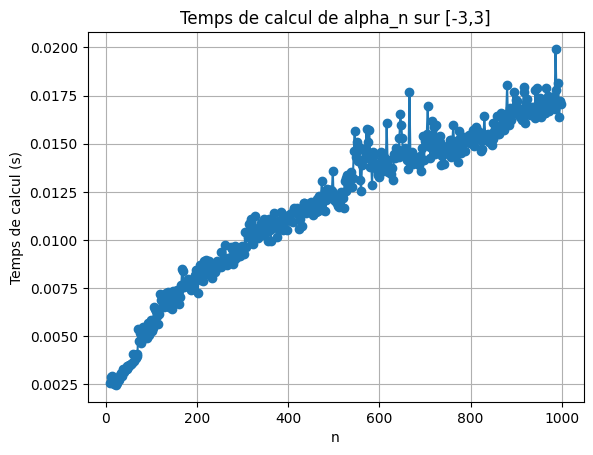

In [10]:
import numpy as np
import time
import matplotlib.pyplot as plt
from math import sqrt, floor, ceil
from scipy.stats import poisson, norm


def alpha_n(n):
    """Calcule alpha_n en restreignant x à [-3,3]"""
    
    k_min = max(0, int(ceil(n - 3 * sqrt(n))))
    k_max = int(floor(n + 3 * sqrt(n)))
    
    alpha = 0.0
    
    for k in range(k_min, k_max + 1):
        x = (k - n) / sqrt(n)
        
        # deux côtés du saut
        Fk = poisson.cdf(k, n)
        Fk_minus = poisson.cdf(k - 1, n) if k > 0 else 0.0
        Phi = norm.cdf(x)
        
        alpha = max(alpha, abs(Fk - Phi), abs(Fk_minus - Phi))
    
    return alpha


# valeurs de n à tester
n_values = np.arange(10, 1000, 2)

times = []

for n in n_values:
    start = time.time()
    alpha_n(n)
    end = time.time()
    
    times.append(end - start)

# plot
plt.figure()
plt.plot(n_values, times, marker='o')
plt.xlabel("n")
plt.ylabel("Temps de calcul (s)")
plt.title("Temps de calcul de alpha_n sur [-3,3]")
plt.grid()
plt.show()

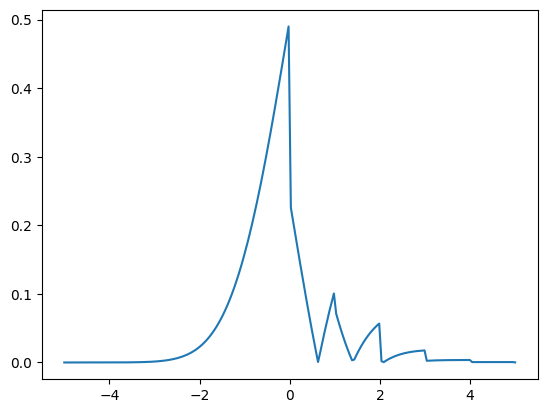

In [30]:
plt.plot(x, np.abs(S_x_etendu-F))